## limb spectra from Kwasan
ILAS 2021

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

dir='D:/data/kwasan/20191009_FeIscan/'
file_w = dir+'Fe_20191009_142717.726_W-limb.fits'
file_e = dir+'Fe_20191009_142921.257_E-limb.fits'
file_c = dir+'Fe_20191009_142819.255_center.fits'

In [49]:
#  read fits data
de = fits.open(file_e); hde = de[0].header ; spe = de[0].data ; spe = np.flip(spe,axis=1)
dw = fits.open(file_w); hdw = dw[0].header ; spw = dw[0].data ; spw = np.flip(spw,axis=1)
spw.shape, spe.shape

((1200, 1600), (1200, 1600))

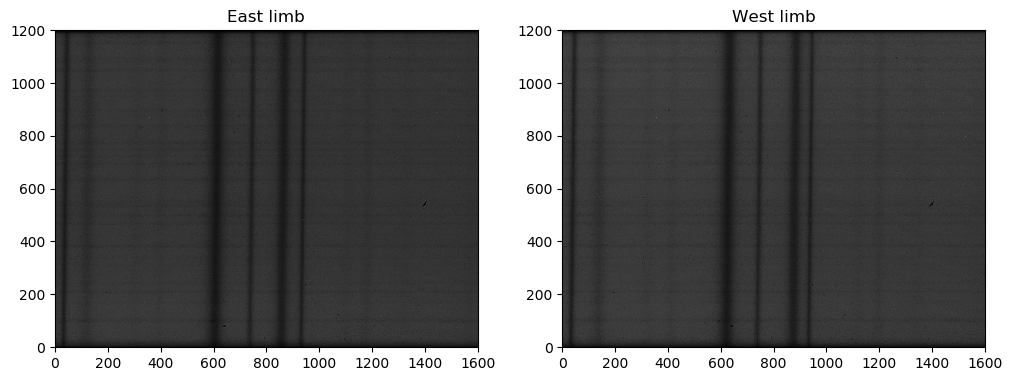

In [77]:
fig,ax = plt.subplots(1,2,figsize=(12,6),dpi=100)
ax[0].imshow(spe, cmap="gray", origin="lower");
ax[0].set_title('East limb')
ax[1].imshow(spw, cmap="gray", origin="lower");
ax[1].set_title('West limb')
plt.show();

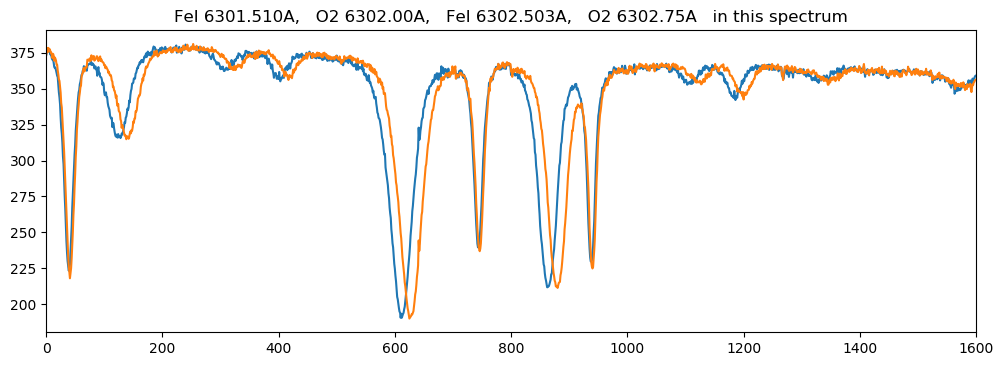

In [83]:
# plot spctra
def rebin(arr, new_shape):   # https://scipython.com/blog/binning-a-2d-array-in-numpy/
    shape = (new_shape[0], arr.shape[0] // new_shape[0],
             new_shape[1], arr.shape[1] // new_shape[1])
    return arr.reshape(shape).mean(-1).mean(1)

spe1=rebin(spe,(12,1600)) ; spe1=spe1[6,:]
spw1=rebin(spw,(12,1600)) ; spw1=spw1[6,:]
fig,ax = plt.subplots(1,1,figsize=(12,4),dpi=100)
ax.plot(spe1+10)  
ax.plot(spw1)
ax.set_xlim(0,1600)
plt.title('FeI 6301.510A,   O2 6302.00A,   FeI 6302.503A,   O2 6302.75A   in this spectrum')
plt.show();